# XGBoost Model Training and Evaluation

This notebook trains and compares two predefined XGBoost classifiers for the explainable credit-risk study. It preserves the held-out test set for final evaluation: no hyperparameters or decision thresholds are fitted using test data. SHAP, LIME, and DiCE are intentionally deferred.

In [1]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
DECISION_THRESHOLD = 0.50
TARGET = "TARGET"

## 1. Load Data and Configuration

In [2]:
DATA_PATH = Path("../data/raw/application_train.csv")
PRIMARY_FEATURES_PATH = Path("../artifacts/primary_features.json")
PREPROCESSOR_PATH = Path("../artifacts/preprocessor.joblib")

ORIGINAL_FEATURES = [
    "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT",
    "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_EMPLOYED",
    "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE", "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]

raw_df = pd.read_csv(DATA_PATH)
with PRIMARY_FEATURES_PATH.open(encoding="utf-8") as file:
    saved_modelling_features = json.load(file)
preprocessor = joblib.load(PREPROCESSOR_PATH)

required_columns = ORIGINAL_FEATURES + [TARGET]
missing_columns = sorted(set(required_columns).difference(raw_df.columns))
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

modelling_df = raw_df[required_columns].copy()
employment_days = modelling_df["DAYS_EMPLOYED"].mask(
    modelling_df["DAYS_EMPLOYED"].eq(365243), np.nan
)
modelling_df["EMPLOYMENT_YEARS"] = employment_days.abs().div(365.25)
modelling_df = modelling_df.drop(columns=["DAYS_EMPLOYED"])

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.mask(denominator.eq(0), np.nan))

modelling_df["CREDIT_INCOME_RATIO"] = safe_ratio(modelling_df["AMT_CREDIT"], modelling_df["AMT_INCOME_TOTAL"])
modelling_df["ANNUITY_INCOME_RATIO"] = safe_ratio(modelling_df["AMT_ANNUITY"], modelling_df["AMT_INCOME_TOTAL"])
modelling_df["CREDIT_ANNUITY_RATIO"] = safe_ratio(modelling_df["AMT_CREDIT"], modelling_df["AMT_ANNUITY"])
modelling_df.replace([np.inf, -np.inf], np.nan, inplace=True)

modelling_feature_names = modelling_df.columns.drop(TARGET).tolist()
if modelling_feature_names != saved_modelling_features:
    raise ValueError("Recreated modelling features or their order do not match primary_features.json.")

print(f"Raw shape: {raw_df.shape}")
print(f"Original selected features: {len(ORIGINAL_FEATURES)}")
print(f"Final modelling features: {len(modelling_feature_names)}")

Raw shape: (307511, 122)
Original selected features: 12
Final modelling features: 15


## 2. Recreate the Exact Train/Test Split

In [3]:
X = modelling_df[modelling_feature_names].copy()
y = modelling_df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
train_positive_rate = y_train.mean()
test_positive_rate = y_test.mean()

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print("Training TARGET counts:")
display(y_train.value_counts().sort_index())
print(f"Training TARGET 1 percentage: {train_positive_rate * 100:.4f}%")
print("Test TARGET counts:")
display(y_test.value_counts().sort_index())
print(f"Test TARGET 1 percentage: {test_positive_rate * 100:.4f}%")

Training rows: 246008
Test rows: 61503
Training TARGET counts:


TARGET
0    226148
1     19860
Name: count, dtype: int64

Training TARGET 1 percentage: 8.0729%
Test TARGET counts:


TARGET
0    56538
1     4965
Name: count, dtype: int64

Test TARGET 1 percentage: 8.0728%


## 3. Apply the Saved Preprocessor

The fitted preprocessor is loaded and used only through `transform`; it is not refitted in this notebook.

In [4]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

def count_nan(matrix):
    values = matrix.data if hasattr(matrix, "data") and not isinstance(matrix, np.ndarray) else np.asarray(matrix)
    return int(np.isnan(values).sum())

processed_nan_count = count_nan(X_train_processed) + count_nan(X_test_processed)
print(f"Processed train rows: {X_train_processed.shape[0]}")
print(f"Processed test rows: {X_test_processed.shape[0]}")
print(f"Transformed feature count: {len(feature_names)}")
print(f"Remaining NaN values: {processed_nan_count}")
assert processed_nan_count == 0

Processed train rows: 246008
Processed test rows: 61503
Transformed feature count: 28
Remaining NaN values: 0


## 4. Calculate the Class-Imbalance Ratio

In [5]:
negative_count = int(y_train.eq(0).sum())
positive_count = int(y_train.eq(1).sum())
calculated_scale_pos_weight = negative_count / positive_count
print(f"Training negatives: {negative_count}")
print(f"Training positives: {positive_count}")
print(f"Calculated scale_pos_weight: {calculated_scale_pos_weight:.6f}")

Training negatives: 226148
Training positives: 19860
Calculated scale_pos_weight: 11.387110


## 5. Trivial Majority-Class Reference

Predicting class 0 for every applicant is not an ML model. It illustrates why high plain accuracy can coexist with complete failure to identify the minority class.

In [6]:
majority_predictions = np.zeros(len(y_test), dtype=int)
majority_metrics = {
    "model": "Majority Reference",
    "roc_auc": np.nan,
    "pr_auc": np.nan,
    "accuracy": accuracy_score(y_test, majority_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, majority_predictions),
    "precision_positive": precision_score(y_test, majority_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, majority_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, majority_predictions, zero_division=0),
    "training_time_seconds": 0.0,
}
display(pd.Series(majority_metrics, name="value").to_frame())

,value
model,Majority Reference
roc_auc,NaN
pr_auc,NaN
accuracy,0.919272
balanced_accuracy,0.5
precision_positive,0.0
recall_positive,0.0
f1_positive,0.0
training_time_seconds,0.0


## 6. Train Baseline XGBoost

In [7]:
COMMON_MODEL_PARAMETERS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
baseline_model = XGBClassifier(**COMMON_MODEL_PARAMETERS)
baseline_start = time.perf_counter()
baseline_model.fit(X_train_processed, y_train)
baseline_training_time = time.perf_counter() - baseline_start
print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Baseline training time: 6.98 seconds


## 7. Evaluate Baseline XGBoost

In [8]:
def evaluate_model(name, model, X_processed, y_true, training_time):
    probabilities = model.predict_proba(X_processed)[:, 1]
    predictions = (probabilities >= DECISION_THRESHOLD).astype(int)
    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision_positive": precision_score(y_true, predictions, zero_division=0),
        "recall_positive": recall_score(y_true, predictions, zero_division=0),
        "f1_positive": f1_score(y_true, predictions, zero_division=0),
        "training_time_seconds": training_time,
    }
    return metrics, probabilities, predictions, confusion_matrix(y_true, predictions)

baseline_metrics, baseline_probabilities, baseline_predictions, baseline_confusion = evaluate_model(
    "Baseline XGBoost", baseline_model, X_test_processed, y_test, baseline_training_time
)
display(pd.Series(baseline_metrics, name="value").to_frame())
display(pd.DataFrame(baseline_confusion, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))
print(classification_report(y_test, baseline_predictions, digits=4, zero_division=0))

,value
model,Baseline XGBoost
roc_auc,0.692892
pr_auc,0.168248
accuracy,0.919272
balanced_accuracy,0.5
precision_positive,0.0
recall_positive,0.0
f1_positive,0.0
training_time_seconds,6.982156


,Predicted 0,Predicted 1
Actual 0,56538,0
Actual 1,4965,0


              precision    recall  f1-score   support

           0     0.9193    1.0000    0.9579     56538
           1     0.0000    0.0000    0.0000      4965

    accuracy                         0.9193     61503
   macro avg     0.4596    0.5000    0.4790     61503
weighted avg     0.8451    0.9193    0.8806     61503



## 8. Train Class-Weighted XGBoost

In [9]:
weighted_model = XGBClassifier(
    **COMMON_MODEL_PARAMETERS,
    scale_pos_weight=calculated_scale_pos_weight,
)
weighted_start = time.perf_counter()
weighted_model.fit(X_train_processed, y_train)
weighted_training_time = time.perf_counter() - weighted_start
print(f"Weighted training time: {weighted_training_time:.2f} seconds")

Weighted training time: 6.12 seconds


## 9. Evaluate Weighted XGBoost

In [10]:
weighted_metrics, weighted_probabilities, weighted_predictions, weighted_confusion = evaluate_model(
    "Weighted XGBoost", weighted_model, X_test_processed, y_test, weighted_training_time
)
display(pd.Series(weighted_metrics, name="value").to_frame())
display(pd.DataFrame(weighted_confusion, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))
print(classification_report(y_test, weighted_predictions, digits=4, zero_division=0))

,value
model,Weighted XGBoost
roc_auc,0.692518
pr_auc,0.167144
accuracy,0.658114
balanced_accuracy,0.641438
precision_positive,0.138796
recall_positive,0.621551
f1_positive,0.22692
training_time_seconds,6.124231


,Predicted 0,Predicted 1
Actual 0,37390,19148
Actual 1,1879,3086


              precision    recall  f1-score   support

           0     0.9522    0.6613    0.7805     56538
           1     0.1388    0.6216    0.2269      4965

    accuracy                         0.6581     61503
   macro avg     0.5455    0.6414    0.5037     61503
weighted avg     0.8865    0.6581    0.7358     61503



## 10. Model Comparison

In [11]:
model_comparison = pd.DataFrame([majority_metrics, baseline_metrics, weighted_metrics])
model_comparison = model_comparison.sort_values(
    ["pr_auc", "balanced_accuracy"], ascending=False, na_position="last"
).reset_index(drop=True)
display(model_comparison)

,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,training_time_seconds
0,Baseline XGBoost,0.692892,0.168248,0.919272,0.500000,0.000000,0.000000,0.00000,6.982156
1,Weighted XGBoost,0.692518,0.167144,0.658114,0.641438,0.138796,0.621551,0.22692,6.124231
2,Majority Reference,NaN,NaN,0.919272,0.500000,0.000000,0.000000,0.00000,0.000000


## 11. ROC Curves

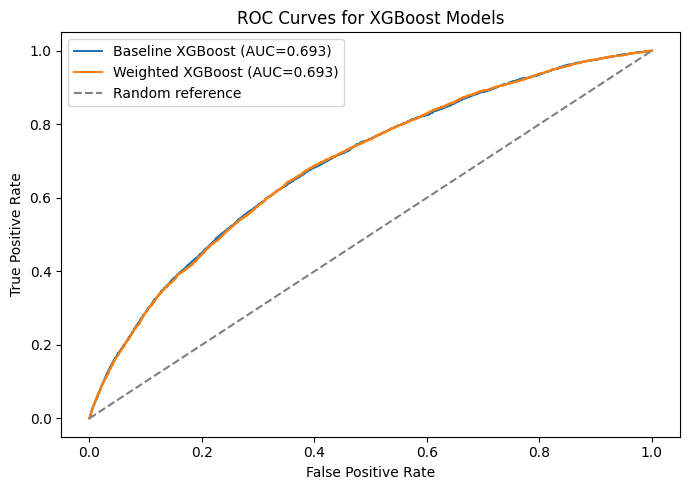

In [12]:
plt.figure(figsize=(7, 5))
for label, probabilities in [("Baseline XGBoost", baseline_probabilities), ("Weighted XGBoost", weighted_probabilities)]:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{label} (AUC={roc_auc_score(y_test, probabilities):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="Random reference")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for XGBoost Models")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Precision–Recall Curves

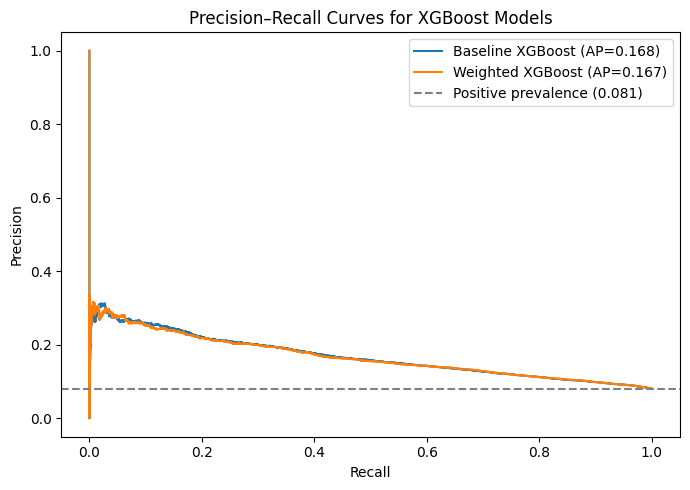

In [13]:
plt.figure(figsize=(7, 5))
for label, probabilities in [("Baseline XGBoost", baseline_probabilities), ("Weighted XGBoost", weighted_probabilities)]:
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    plt.plot(recall, precision, label=f"{label} (AP={average_precision_score(y_test, probabilities):.3f})")
plt.axhline(test_positive_rate, linestyle="--", color="grey", label=f"Positive prevalence ({test_positive_rate:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for XGBoost Models")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

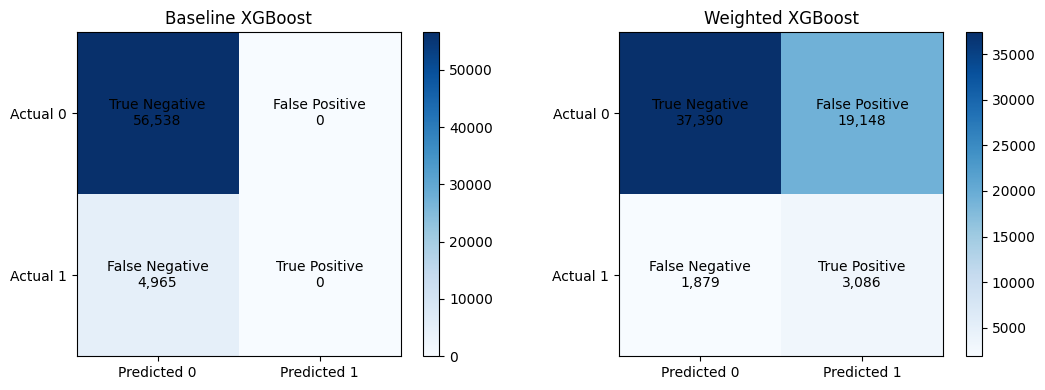

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = np.array([["True Negative", "False Positive"], ["False Negative", "True Positive"]])
for axis, title, matrix in zip(axes, ["Baseline XGBoost", "Weighted XGBoost"], [baseline_confusion, weighted_confusion]):
    image = axis.imshow(matrix, cmap="Blues")
    for row in range(2):
        for column in range(2):
            axis.text(column, row, f"{labels[row, column]}\n{matrix[row, column]:,}", ha="center", va="center")
    axis.set_xticks([0, 1], ["Predicted 0", "Predicted 1"])
    axis.set_yticks([0, 1], ["Actual 0", "Actual 1"])
    axis.set_title(title)
    fig.colorbar(image, ax=axis, fraction=0.046)
plt.tight_layout()
plt.show()

## 14. Threshold Analysis

The default 0.5 threshold is not automatically optimal. Changing it trades false positives against false negatives, and a financial institution would require an explicit policy- and risk-based decision. This descriptive test-set analysis does not choose a threshold by maximising test performance. The XAI study retains 0.5 unless a later methodology decision is documented; no universal regulatory threshold is claimed.

In [15]:
threshold_records = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (weighted_probabilities >= threshold).astype(int)
    threshold_records.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_predictions, zero_division=0),
        "recall": recall_score(y_test, threshold_predictions, zero_division=0),
        "f1": f1_score(y_test, threshold_predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, threshold_predictions),
        "predicted_positive_count": int(threshold_predictions.sum()),
    })
threshold_analysis = pd.DataFrame(threshold_records)
display(threshold_analysis)

,threshold,precision,recall,f1,balanced_accuracy,predicted_positive_count
0,0.3,0.090493,0.955488,0.165328,0.556081,52424
1,0.4,0.107648,0.836052,0.190737,0.613718,38561
2,0.5,0.138796,0.621551,0.226920,0.641438,22234
3,0.6,0.179344,0.387513,0.245205,0.615897,10728
4,0.7,0.227625,0.171601,0.195682,0.560234,3743


## 15. Feature-Importance Sanity Check

Built-in XGBoost importance is used only as a model sanity check. It is not the final explanation method: SHAP, LIME, and DiCE will be evaluated separately in later stages.

,feature,importance
0,categorical__NAME_INCOME_TYPE_Working,0.137693
1,categorical__NAME_CONTRACT_TYPE_Revolving loans,0.119810
2,categorical__NAME_CONTRACT_TYPE_Cash loans,0.108939
3,numeric__EMPLOYMENT_YEARS,0.074755
4,numeric__CREDIT_ANNUITY_RATIO,0.062844
5,categorical__NAME_INCOME_TYPE_Commercial assoc...,0.057581
6,categorical__NAME_INCOME_TYPE_Pensioner,0.052509
7,numeric__AMT_GOODS_PRICE,0.048873
8,categorical__NAME_HOUSING_TYPE_House / apartment,0.034581
9,numeric__AMT_CREDIT,0.034455


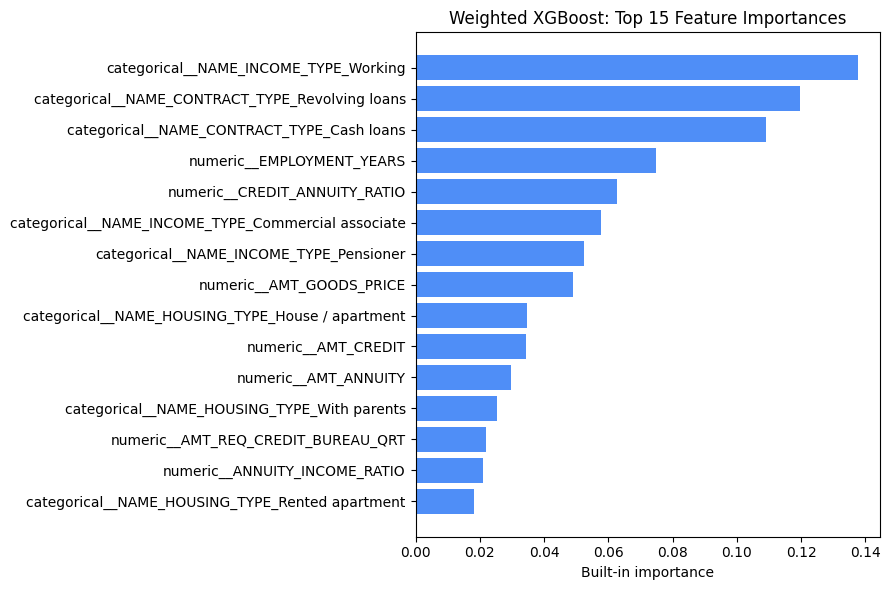

In [16]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": weighted_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
top_15_importance = feature_importance.head(15)
display(top_15_importance)

plot_data = top_15_importance.sort_values("importance")
plt.figure(figsize=(9, 6))
plt.barh(plot_data["feature"], plot_data["importance"], color="#4F8EF7")
plt.xlabel("Built-in importance")
plt.title("Weighted XGBoost: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 16. Select the Final Model

Selection uses the predefined comparison at threshold 0.5 and considers ranking performance alongside minority-class recall, F1, and balanced accuracy. Accuracy alone is not a selection criterion. This is model comparison, not hyperparameter or threshold tuning.

In [17]:
ranking_preserved = (
    weighted_metrics["roc_auc"] >= baseline_metrics["roc_auc"] - 0.02
    and weighted_metrics["pr_auc"] >= baseline_metrics["pr_auc"] - 0.02
)
minority_tradeoff_improved = (
    weighted_metrics["recall_positive"] > baseline_metrics["recall_positive"]
    and weighted_metrics["balanced_accuracy"] > baseline_metrics["balanced_accuracy"]
    and weighted_metrics["f1_positive"] >= baseline_metrics["f1_positive"]
)

if ranking_preserved and minority_tradeoff_improved:
    final_model_name = "Weighted XGBoost"
    final_model = weighted_model
    final_metrics = weighted_metrics
    final_confusion = weighted_confusion
else:
    final_model_name = "Baseline XGBoost"
    final_model = baseline_model
    final_metrics = baseline_metrics
    final_confusion = baseline_confusion

print(f"Ranking performance preserved by weighted model: {ranking_preserved}")
print(f"Minority-class trade-off improved by weighted model: {minority_tradeoff_improved}")
print(f"Selected final model: {final_model_name}")
display(pd.DataFrame([baseline_metrics, weighted_metrics]).set_index("model"))

Ranking performance preserved by weighted model: True
Minority-class trade-off improved by weighted model: True
Selected final model: Weighted XGBoost


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,training_time_seconds
model,,,,,,,,
Baseline XGBoost,0.692892,0.168248,0.919272,0.500000,0.000000,0.000000,0.00000,6.982156
Weighted XGBoost,0.692518,0.167144,0.658114,0.641438,0.138796,0.621551,0.22692,6.124231


## 17–20. Save the Final Model, Metadata, Split Indexes, and Results

In [18]:
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_JOBLIB_PATH = ARTIFACTS_DIR / "xgboost_credit_model.joblib"
MODEL_NATIVE_PATH = ARTIFACTS_DIR / "xgboost_credit_model.json"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
TRAIN_INDICES_PATH = ARTIFACTS_DIR / "train_indices.csv"
TEST_INDICES_PATH = ARTIFACTS_DIR / "test_indices.csv"
MODEL_COMPARISON_PATH = ARTIFACTS_DIR / "model_comparison.csv"
THRESHOLD_ANALYSIS_PATH = ARTIFACTS_DIR / "threshold_analysis.csv"

joblib.dump(final_model, MODEL_JOBLIB_PATH)
final_model.save_model(MODEL_NATIVE_PATH)
pd.DataFrame({"row_index": X_train.index}).to_csv(TRAIN_INDICES_PATH, index=False)
pd.DataFrame({"row_index": X_test.index}).to_csv(TEST_INDICES_PATH, index=False)
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
threshold_analysis.to_csv(THRESHOLD_ANALYSIS_PATH, index=False)

model_metadata = {
    "project_model": "XGBoost",
    "selected_model": final_model_name,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "decision_threshold": DECISION_THRESHOLD,
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "original_feature_count": len(ORIGINAL_FEATURES),
    "transformed_feature_count": len(feature_names),
    "scale_pos_weight": float(calculated_scale_pos_weight),
    "model_parameters": final_model.get_params(),
    "roc_auc": float(final_metrics["roc_auc"]),
    "pr_auc": float(final_metrics["pr_auc"]),
    "accuracy": float(final_metrics["accuracy"]),
    "balanced_accuracy": float(final_metrics["balanced_accuracy"]),
    "precision_positive": float(final_metrics["precision_positive"]),
    "recall_positive": float(final_metrics["recall_positive"]),
    "f1_positive": float(final_metrics["f1_positive"]),
    "confusion_matrix": final_confusion.astype(int).tolist(),
    "target_positive_rate_train": float(train_positive_rate),
    "target_positive_rate_test": float(test_positive_rate),
    "training_date": datetime.now(timezone.utc).isoformat(),
}
with MODEL_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(model_metadata, file, indent=2)

## 21. Final Quality Checks

In [19]:
assert hasattr(final_model, "classes_"), "Final model is not fitted."
verification_probabilities = final_model.predict_proba(X_test_processed)[:, 1]
assert verification_probabilities.shape[0] == len(y_test)
assert np.isfinite(verification_probabilities).all()
assert ((verification_probabilities >= 0) & (verification_probabilities <= 1)).all()
assert final_model.get_booster().num_boosted_rounds() > 0
assert MODEL_JOBLIB_PATH.exists() and MODEL_NATIVE_PATH.exists()
assert MODEL_METADATA_PATH.exists()
assert TEST_INDICES_PATH.exists() and TRAIN_INDICES_PATH.exists()
print("Quality checks passed. Both models were fitted only with X_train_processed and y_train.")

Quality checks passed. Both models were fitted only with X_train_processed and y_train.


## Model Training Interpretation

- **Class imbalance:** _Discuss how the small TARGET 1 class affects learning and evaluation._
- **Accuracy limitation:** _Explain why majority-class accuracy can conceal failure to identify credit risk._
- **ROC-AUC and PR-AUC:** _Discuss ranking across classes and precision–recall performance under imbalance._
- **Positive-class recall and F1:** _Discuss missed-risk cases and the precision–recall balance._
- **`scale_pos_weight`:** _Discuss its role in changing the training emphasis placed on minority examples._
- **Training versus explanation:** _Distinguish predictive model construction from later SHAP, LIME, and DiCE evaluation._
- **Unseen test set:** _Explain why test observations are excluded from fitting and preprocessing estimation._
- **Decision threshold:** _Discuss why the retained threshold must be explicit and policy-dependent._
- **Frozen final model:** _Explain why one saved model is fixed before comparing explanation methods._

These are discussion prompts, not final dissertation conclusions.

## 23. Final Summary

In [20]:
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Transformed feature count: {len(feature_names)}")
print(f"Training TARGET 1 percentage: {train_positive_rate * 100:.4f}%")
print(f"Test TARGET 1 percentage: {test_positive_rate * 100:.4f}%")
print(f"scale_pos_weight: {calculated_scale_pos_weight:.6f}")
print(f"Baseline ROC-AUC: {baseline_metrics['roc_auc']:.6f}")
print(f"Baseline PR-AUC: {baseline_metrics['pr_auc']:.6f}")
print(f"Weighted ROC-AUC: {weighted_metrics['roc_auc']:.6f}")
print(f"Weighted PR-AUC: {weighted_metrics['pr_auc']:.6f}")
print(f"Selected final model: {final_model_name}")
print(f"Decision threshold: {DECISION_THRESHOLD:.2f}")
print(f"Final positive-class precision: {final_metrics['precision_positive']:.6f}")
print(f"Final positive-class recall: {final_metrics['recall_positive']:.6f}")
print(f"Final positive-class F1: {final_metrics['f1_positive']:.6f}")
print(f"Model saved: {MODEL_JOBLIB_PATH.exists() and MODEL_NATIVE_PATH.exists()}")
print(f"Model metadata saved: {MODEL_METADATA_PATH.exists()}")
print(f"Train/test indices saved: {TRAIN_INDICES_PATH.exists() and TEST_INDICES_PATH.exists()}")

Training rows: 246008
Test rows: 61503
Transformed feature count: 28
Training TARGET 1 percentage: 8.0729%
Test TARGET 1 percentage: 8.0728%
scale_pos_weight: 11.387110
Baseline ROC-AUC: 0.692892
Baseline PR-AUC: 0.168248
Weighted ROC-AUC: 0.692518
Weighted PR-AUC: 0.167144
Selected final model: Weighted XGBoost
Decision threshold: 0.50
Final positive-class precision: 0.138796
Final positive-class recall: 0.621551
Final positive-class F1: 0.226920
Model saved: True
Model metadata saved: True
Train/test indices saved: True
